In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

Load all five files

In [31]:
transactions = pd.read_csv("C:/Users/Admin/OneDrive - UWA/Projects/Data Engineering/Data-Engineering/Transaction Fraud Detection Project/Data/Raw/transactions.csv")
account_profiles = pd.read_csv("C:/Users/Admin/OneDrive - UWA/Projects/Data Engineering/Data-Engineering/Transaction Fraud Detection Project/Data/Raw/account_profiles.csv")
fraud_patterns = pd.read_csv("C:/Users/Admin/OneDrive - UWA/Projects/Data Engineering/Data-Engineering/Transaction Fraud Detection Project/Data/Raw/fraud_patterns.csv")
network_edges = pd.read_csv("C:/Users/Admin/OneDrive - UWA/Projects/Data Engineering/Data-Engineering/Transaction Fraud Detection Project/Data/Raw/network_edges.csv")
time_series_stats = pd.read_csv("C:/Users/Admin/OneDrive - UWA/Projects/Data Engineering/Data-Engineering/Transaction Fraud Detection Project/Data/Raw/time_series_stats.csv")  

Check the size of all the files

In [32]:
print("File shapes:")
print(f"  transactions      : {transactions.shape[0]:>9,} rows  x {transactions.shape[1]:>2} cols")
print(f"  account_profiles  : {account_profiles.shape[0]:>9,} rows  x {account_profiles.shape[1]:>2} cols")
print(f"  network_edges     : {network_edges.shape[0]:>9,} rows  x {network_edges.shape[1]:>2} cols")
print(f"  time_series_stats : {time_series_stats.shape[0]:>9,} rows  x {time_series_stats.shape[1]:>2} cols")
print(f"  fraud_patterns    : {fraud_patterns.shape[0]:>9,} rows  x {fraud_patterns.shape[1]:>2} cols")

File shapes:
  transactions      : 1,000,000 rows  x 23 cols
  account_profiles  :    50,000 rows  x 23 cols
  network_edges     :     7,411 rows  x  6 cols
  time_series_stats :    26,280 rows  x 10 cols
  fraud_patterns    :         7 rows  x 12 cols


Data quality check

In [33]:
print("transaction.csv - missing values")
missing = transactions.isnull().sum()
print(missing[missing > 0].rename("missing count"))
print("Only fraud_pattern should have missing values (null = legitimate transactions)")

print("\ntransactions.csv - dtypes")
print(transactions.dtypes)

print(f"\nDuplicate transactions IDs: {transactions["transaction_id"].duplicated().sum()}")
print(f"\nNegative amounts: {(transactions["amount"] <= 0).sum()}")
print(f"\nDate range: {transactions["timestamp"].min()} to {transactions["timestamp"].max()}")

transaction.csv - missing values
fraud_pattern    982857
Name: missing count, dtype: int64
Only fraud_pattern should have missing values (null = legitimate transactions)

transactions.csv - dtypes
transaction_id          object
account_id              object
timestamp               object
hour_of_day              int64
day_of_week              int64
is_weekend               int64
amount                 float64
merchant_category       object
mcc_code                 int64
merchant_country        object
card_present             int64
device_type             object
device_known             int64
ip_risk_score          float64
is_foreign_txn           int64
time_since_last_s        int64
velocity_1h              int64
amount_vs_avg_ratio    float64
account_age_days         int64
has_2fa                  int64
credit_limit           float64
is_fraud                 int64
fraud_pattern           object
dtype: object

Duplicate transactions IDs: 0

Negative amounts: 0

Date range: 2022-01-01 

In [34]:
print("account_profiles.csv - missing values")
missing = account_profiles.isnull().sum()
print(missing[missing > 0].rename("missing count"))

print("\naccount_profiles.csv - dtypes")
print(account_profiles.dtypes)

account_profiles.csv - missing values
Series([], Name: missing count, dtype: int64)

account_profiles.csv - dtypes
account_id             object
account_age_days        int64
credit_limit          float64
home_country           object
risk_score            float64
is_high_risk            int64
avg_txn_amount        float64
avg_monthly_txns      float64
has_2fa                 int64
account_type           object
total_transactions    float64
total_amount          float64
avg_amount            float64
max_amount            float64
fraud_count           float64
fraud_amount          float64
pct_foreign           float64
avg_velocity          float64
unique_countries      float64
unique_categories     float64
avg_ip_risk           float64
fraud_rate            float64
is_fraudster          float64
dtype: object


In [35]:
print("fraud_patterns.csv - missing values")
missing = fraud_patterns.isnull().sum()
print(missing[missing > 0].rename("missing count"))

print("\nfraud_patterns.csv - dtypes")
print(fraud_patterns.dtypes)

fraud_patterns.csv - missing values
Series([], Name: missing count, dtype: int64)

fraud_patterns.csv - dtypes
fraud_pattern            object
description              object
transaction_count         int64
fraud_share_pct         float64
avg_amount              float64
median_amount           float64
pct_night_0_5           float64
pct_foreign             float64
pct_card_not_present    float64
avg_velocity_1h         float64
avg_ip_risk             float64
pct_no_2fa              float64
dtype: object


In [36]:
print("network_edges.csv - missing values")
missing = network_edges.isnull().sum()
print(missing[missing > 0].rename("missing count"))

print("\nnetwork_edges.csv - dtypes")
print(network_edges.dtypes)

network_edges.csv - missing values
ring_id    3000
Name: missing count, dtype: int64

network_edges.csv - dtypes
account_a           object
account_b           object
shared_type         object
connection_count     int64
ring_id             object
both_fraud           int64
dtype: object


In [37]:
print("time_series_stats.csv - missing values")
missing = time_series_stats.isnull().sum()
print(missing[missing > 0].rename("missing count"))

print("\ntime_series_stats.csv - dtypes")
print(time_series_stats.dtypes)

time_series_stats.csv - missing values
Series([], Name: missing count, dtype: int64)

time_series_stats.csv - dtypes
hour                  object
transaction_count      int64
fraud_count            int64
total_amount         float64
avg_amount           float64
avg_ip_risk          float64
fraud_rate           float64
hour_of_day            int64
day_of_week            int64
is_weekend             int64
dtype: object


Class distribution - fraud vs legitimate

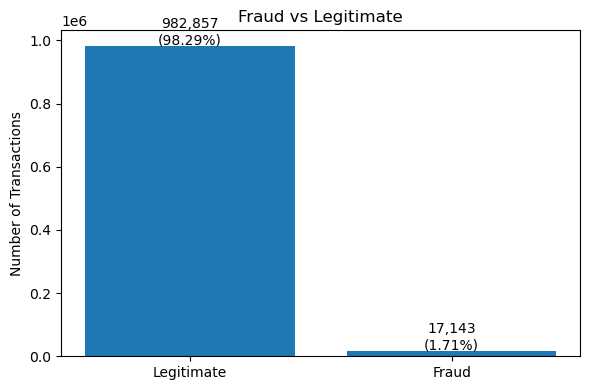

In [59]:

is_fraud_counts = transactions["is_fraud"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Legitimate", "Fraud"], is_fraud_counts.values)
plt.title("Fraud vs Legitimate")
plt.ylabel("Number of Transactions")
for i,v in enumerate(is_fraud_counts.values):
    plt.text(i, v + 5000, f"{v:,}\n({v/len(transactions)*100:.2f}%)", ha="center")
plt.tight_layout()

Fraud by type 

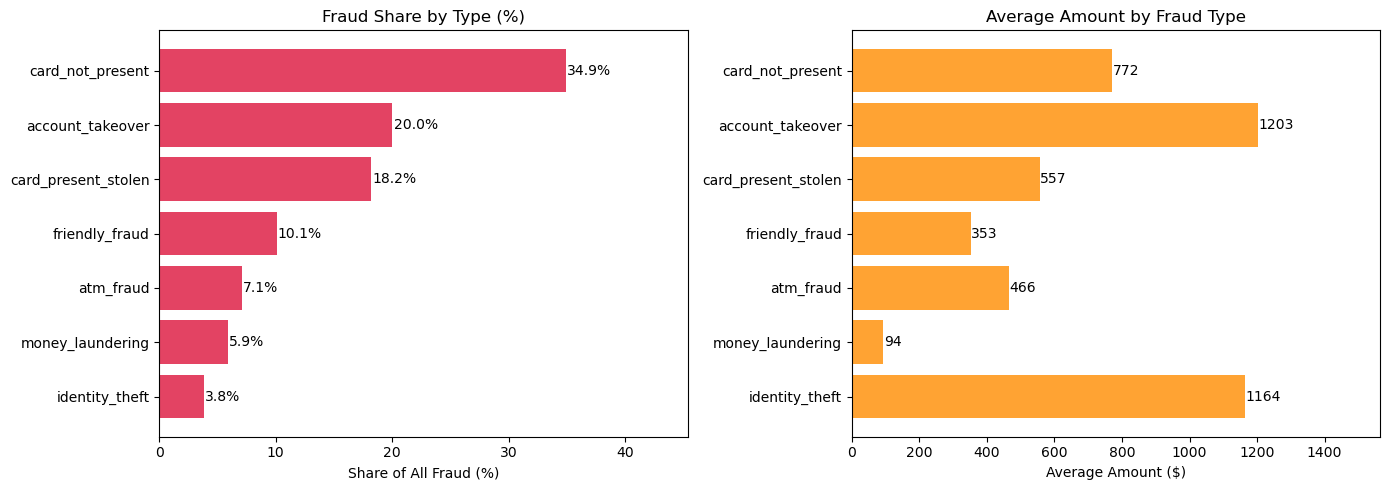

In [72]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

fp = fraud_patterns.sort_values("fraud_share_pct", ascending = True)

#Share %
axes[0].barh(fp["fraud_pattern"], fp["fraud_share_pct"], color = "crimson",alpha = 0.8)
axes[0].set_title("Fraud Share by Type (%)")
axes[0].set_xlabel("Share of All Fraud (%)")
for i, v in enumerate(fp["fraud_share_pct"]):
    axes[0].text(v + 0.1, i, f"{v:.1f}%", va = "center")
axes[0].set_xlim(0, fp["fraud_share_pct"].max() *1.3)

#Average amount
axes[1].barh(fp["fraud_pattern"], fp["avg_amount"], color = "darkorange", alpha = 0.8)
axes[1].set_title("Average Amount by Fraud Type")
axes[1].set_xlabel("Average Amount ($)")
for i,v in enumerate(fp["avg_amount"]):
    axes[1].text(v + 1, i, f"{v:.0f}", va = "center")
axes[1].set_xlim(0, fp["avg_amount"].max() *1.3)


plt.tight_layout()

Hourly fraud rate vs transaction volume

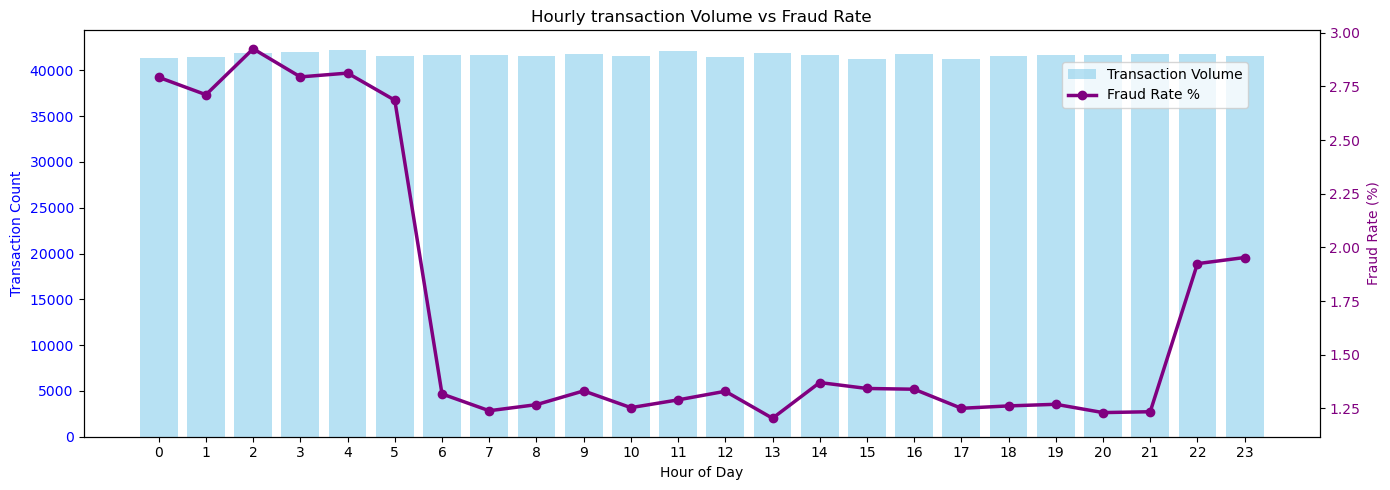

In [80]:
hourly = time_series_stats.groupby("hour_of_day").agg(
    transaction_count = ("transaction_count", "sum"),
    fraud_count = ("fraud_count", "sum")
).reset_index()
hourly["fraud_rate"] = hourly["fraud_count"]/hourly["transaction_count"] * 100

fig, ax1 = plt.subplots(figsize = (14, 5))

ax1.bar(hourly["hour_of_day"], hourly["transaction_count"], color = "skyblue", alpha = 0.6, label = "Transaction Volume")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Transaction Count", color = "blue")
ax1.tick_params(axis = "y", labelcolor = "blue")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(hourly["hour_of_day"], hourly["fraud_rate"], color = "purple",linewidth = 2.5, marker = "o", label = "Fraud Rate %")
ax2.set_ylabel("Fraud Rate (%)", color = "purple")
ax2.tick_params(axis = "y", labelcolor = "purple")

plt.title("Hourly transaction Volume vs Fraud Rate")
fig.legend(loc = "upper right", bbox_to_anchor = (0.9, 0.88))
plt.tight_layout()

Daily fraud rate 2022-2024

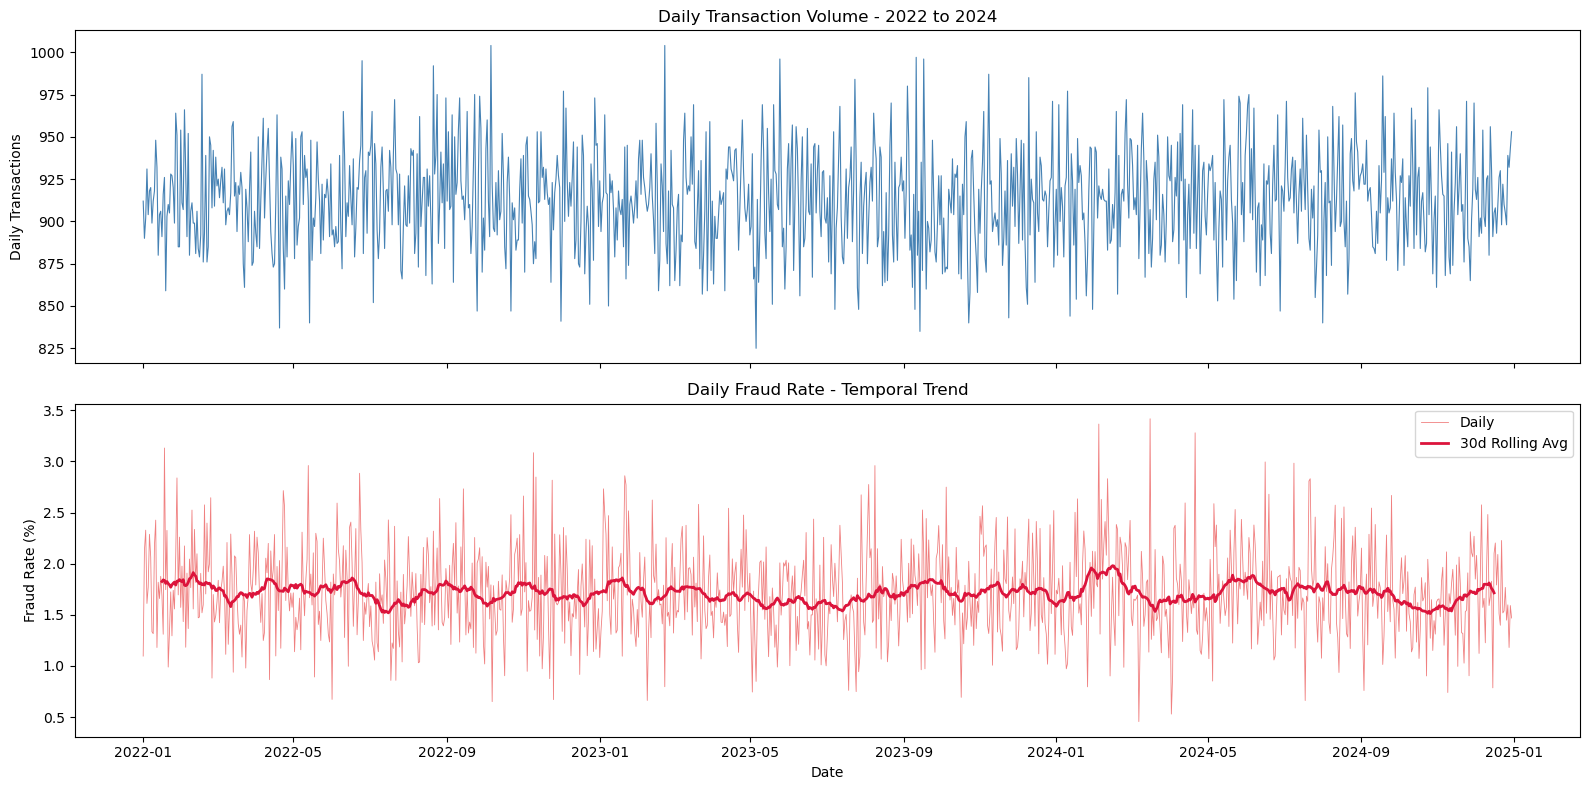

In [84]:
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

daily = transactions.groupby(transactions["timestamp"].dt.date).agg(
    total = ("is_fraud", "count"),
    fraud = ("is_fraud", "sum")
).reset_index()
daily["fraud_rate"]= daily["fraud"] / daily["total"] * 100
daily["timestamp"] = pd.to_datetime(daily["timestamp"])
daily["fraud_rate_30d"] = daily["fraud_rate"].rolling(30, center = True).mean()

fig, axes = plt.subplots(2, 1, figsize = (16, 8), sharex = True)
axes[0].plot(daily["timestamp"], daily["total"], color ="steelblue", linewidth = 0.8)
axes[0].set_ylabel("Daily Transactions")
axes[0].set_title("Daily Transaction Volume - 2022 to 2024")

axes[1].plot(daily["timestamp"], daily["fraud_rate"], color = "lightcoral", linewidth = 0.6, label = "Daily")
axes[1].plot(daily["timestamp"], daily["fraud_rate_30d"], color = "crimson", linewidth = 2, label = "30d Rolling Avg")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlabel("Date")
axes[1].set_title("Daily Fraud Rate - Temporal Trend")
axes[1].legend()

plt.tight_layout()

Amount distribution fraud vs legitimate

C:\Users\Admin\AppData\Local\Temp\ipykernel_68308\3015019106.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


Median - Legitimate: $80.03 | Fraud: $240.74
Mean - Legitimate: $174.21 | Fraud: $730.14


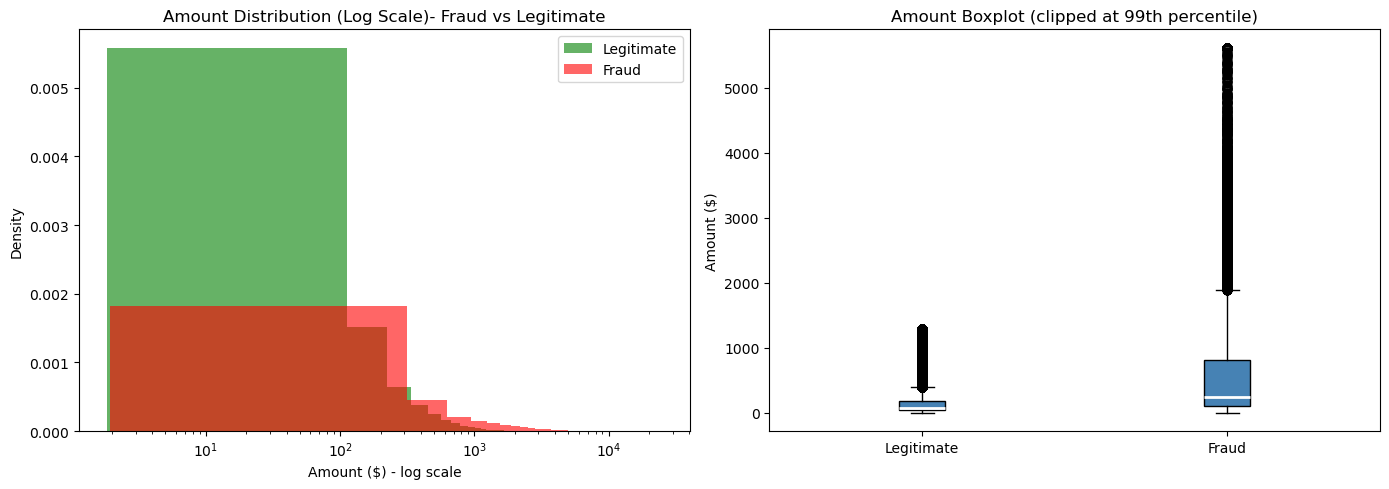

In [88]:
legit = transactions.loc[transactions["is_fraud"] == 0, "amount"]
fraud = transactions.loc[transactions["is_fraud"] == 1, "amount"]

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

#Histogram (log x-axis)
axes[0].hist(legit, bins = 80, color = "green", alpha = 0.6, density = True, label = "Legitimate")
axes[0].hist(fraud, bins = 80, color = "red", alpha = 0.6, density = True, label = "Fraud")
axes[0].set_xscale("log")
axes[0].set_xlabel("Amount ($) - log scale")
axes[0].set_ylabel("Density")
axes[0].set_title("Amount Distribution (Log Scale)- Fraud vs Legitimate")
axes[0].legend()

axes[1].boxplot(
    [legit.clip(upper = legit.quantile(0.99)), fraud.clip(upper = fraud.quantile(0.99))],
    labels = ["Legitimate", "Fraud"],
    patch_artist = True,
    boxprops = dict(facecolor = "steelblue"),
    medianprops = dict(color = "white", linewidth = 2)
)
axes[1].set_ylabel("Amount ($)")
axes[1].set_title("Amount Boxplot (clipped at 99th percentile)")

plt.tight_layout()

print(f"Median - Legitimate: ${legit.median():.2f} | Fraud: ${fraud.median():.2f}")
print(f"Mean - Legitimate: ${legit.mean():.2f} | Fraud: ${fraud.mean():.2f}")

Fraud rate by categorical features

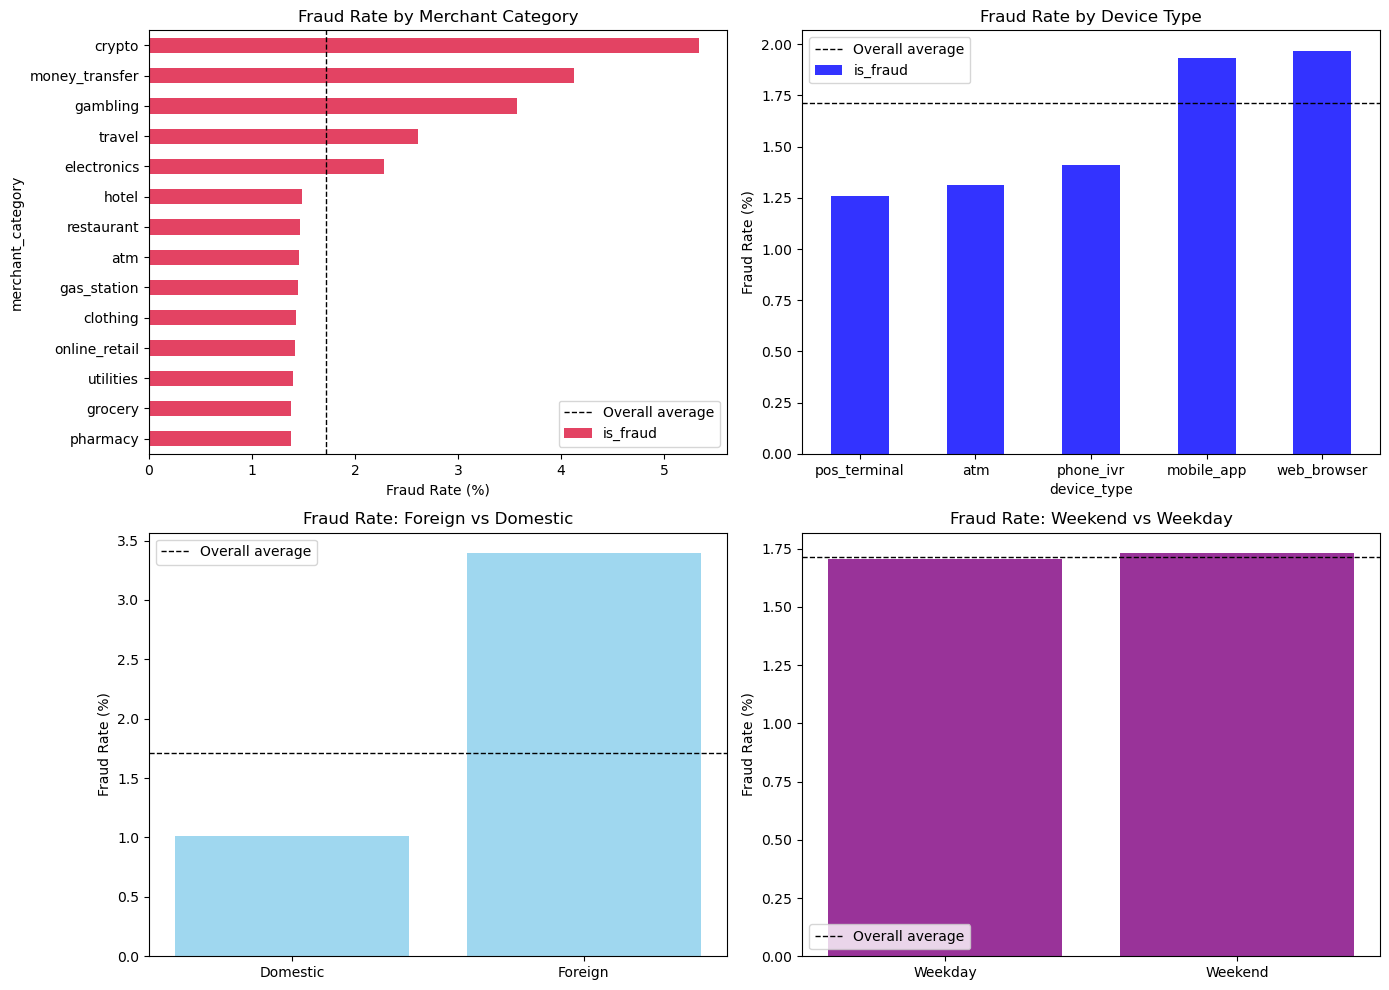

In [92]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

#merchant_category
cat_rates = transactions.groupby("merchant_category")["is_fraud"].mean().sort_values() * 100
cat_rates.plot.barh(ax = axes[0,0], color = "crimson", alpha = 0.8)
axes[0, 0].axvline(transactions["is_fraud"].mean() * 100, color = "black", linestyle="--", linewidth = 1, label = "Overall average")
axes[0, 0].set_title("Fraud Rate by Merchant Category")
axes[0, 0].set_xlabel("Fraud Rate (%)")
axes[0 ,0]. legend()

#device_type
dev_rates = transactions.groupby("device_type")["is_fraud"].mean().sort_values() * 100
dev_rates.plot.bar(ax = axes[0, 1], color = "blue", alpha =0.8, rot = 0)
axes[0 ,1].axhline(transactions["is_fraud"].mean() * 100, color ="black", linestyle = "--", linewidth = 1, label = "Overall average")
axes[0, 1].set_title("Fraud Rate by Device Type")
axes[0, 1].set_ylabel("Fraud Rate (%)")
axes[0, 1].legend()

#is_foreign_txn
foreign_rates = transactions.groupby("is_foreign_txn")["is_fraud"].mean().sort_values() * 100
axes[1, 0].bar(["Domestic", "Foreign"], foreign_rates.values, color = "skyblue", alpha = 0.8)
axes[1, 0].axhline(transactions["is_fraud"].mean() * 100, color = "black", linestyle = "--", linewidth = 1, label = "Overall average")
axes[1, 0].set_title("Fraud Rate: Foreign vs Domestic")
axes[1, 0].set_ylabel("Fraud Rate (%)")
axes[1, 0].legend()

#is_weekend
weekend_rates = transactions.groupby("is_weekend")["is_fraud"].mean().sort_values() * 100
axes[1, 1].bar(["Weekday", "Weekend"], weekend_rates.values, color ="purple", alpha = 0.8)
axes[1, 1].axhline(transactions["is_fraud"].mean() * 100, color = "black", linestyle = "--", linewidth = 1, label = "Overall average")
axes[1, 1].set_title("Fraud Rate: Weekend vs Weekday")
axes[1, 1].set_ylabel("Fraud Rate (%)")
axes[1, 1].legend()

plt.tight_layout()

Account profiles analysis

Top 19.8% of accounts drive 80% of all fraud


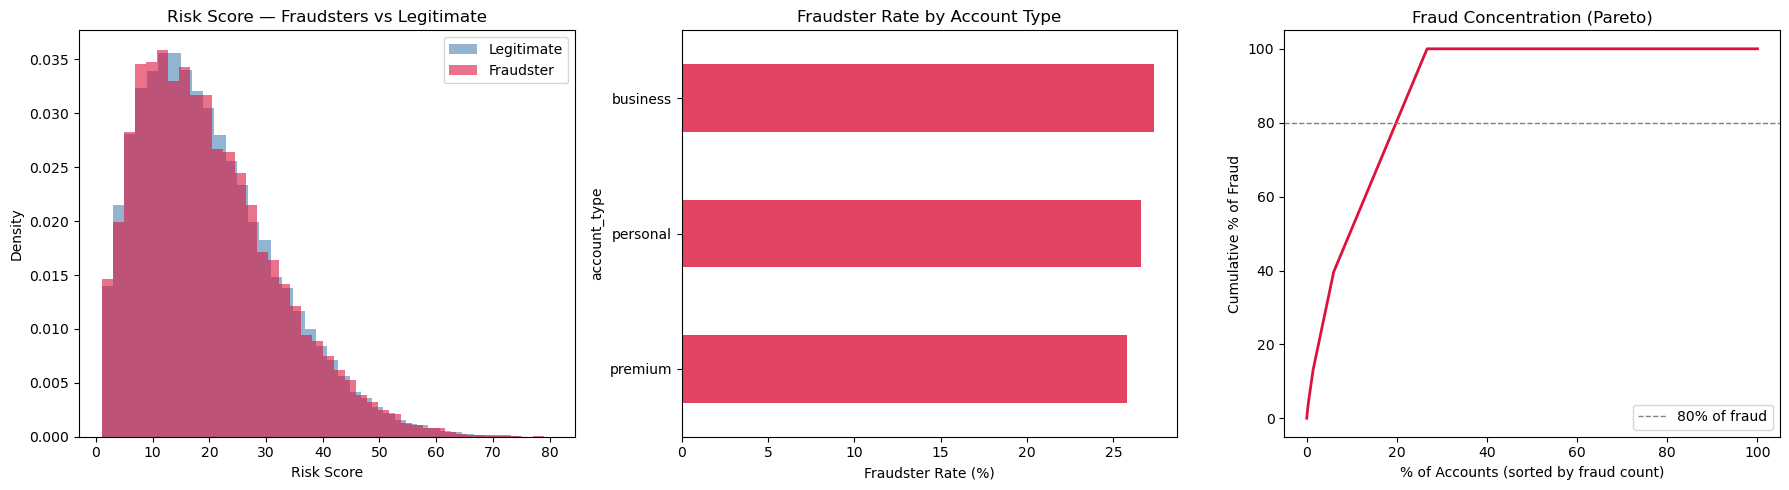

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Risk score distribution: fraudster vs legitimate
fraudsters = account_profiles[account_profiles["is_fraudster"] == 1]["risk_score"]
legit_accts = account_profiles[account_profiles["is_fraudster"] == 0]["risk_score"]
axes[0].hist(legit_accts, bins=40, color="steelblue", alpha=0.6, density=True, label="Legitimate")
axes[0].hist(fraudsters,  bins=40, color="crimson",   alpha=0.6, density=True, label="Fraudster")
axes[0].set_title("Risk Score — Fraudsters vs Legitimate")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Density")
axes[0].legend()

# Fraudster rate by account_type
fraud_by_type = account_profiles.groupby("account_type")["is_fraudster"].mean().sort_values() * 100
fraud_by_type.plot.barh(ax=axes[1], color="crimson", alpha=0.8)
axes[1].set_title("Fraudster Rate by Account Type")
axes[1].set_xlabel("Fraudster Rate (%)")

# Fraud concentration — Pareto curve
acct_sorted = account_profiles.sort_values("fraud_count", ascending=False).reset_index(drop=True)
acct_sorted["cum_fraud_pct"] = acct_sorted["fraud_count"].cumsum() / acct_sorted["fraud_count"].sum() * 100
acct_sorted["pct_accounts"]  = (acct_sorted.index + 1) / len(acct_sorted) * 100
axes[2].plot(acct_sorted["pct_accounts"], acct_sorted["cum_fraud_pct"], color="crimson", linewidth=2)
axes[2].axhline(80, color="gray", linestyle="--", linewidth=1, label="80% of fraud")
axes[2].set_title("Fraud Concentration (Pareto)")
axes[2].set_xlabel("% of Accounts (sorted by fraud count)")
axes[2].set_ylabel("Cumulative % of Fraud")
axes[2].legend()

plt.tight_layout()

top_pct = acct_sorted[acct_sorted["cum_fraud_pct"] <= 80]["pct_accounts"].max()
print(f"Top {top_pct:.1f}% of accounts drive 80% of all fraud")

Behavioural feature distributions

IP Risk Score                            Legitimate median:    18.40  |  Fraud median:    52.90
Velocity (transactions in last 1h)       Legitimate median:     1.00  |  Fraud median:     4.00
Amount vs Account Average Ratio          Legitimate median:     1.27  |  Fraud median:     3.82
Time Since Last Transaction (s)          Legitimate median:   125.00  |  Fraud median:   125.00


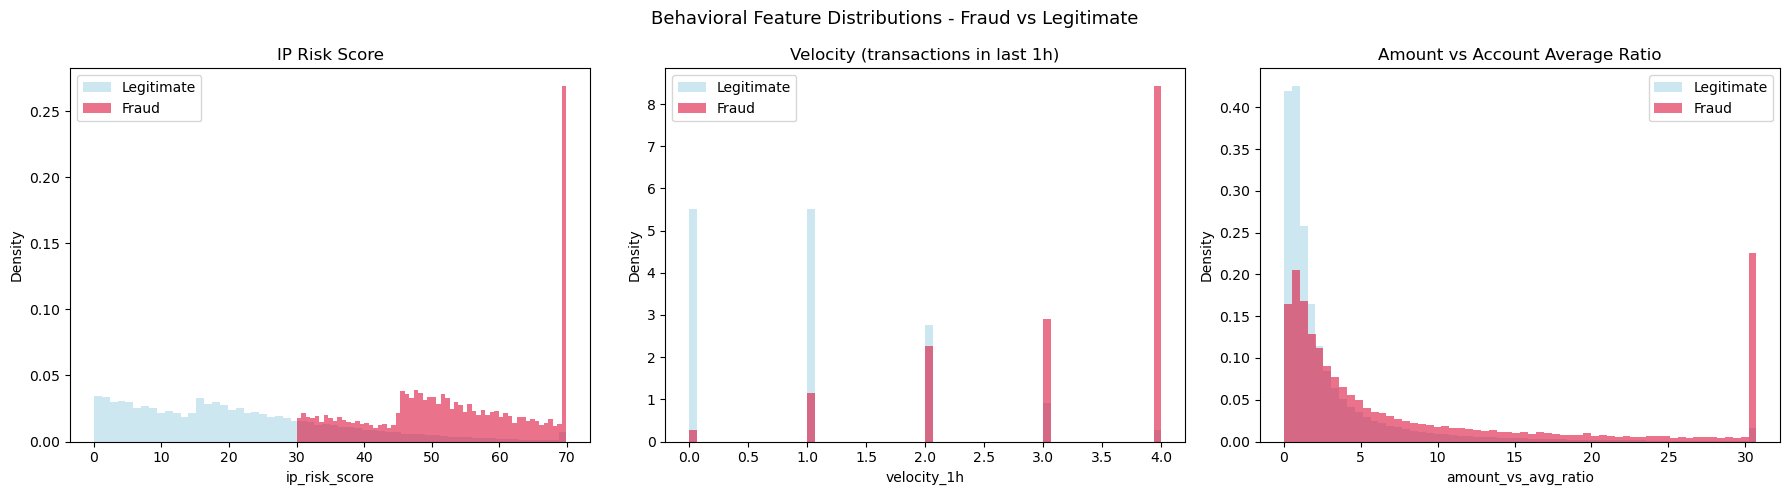

In [95]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

behav_features = [
    ("ip_risk_score", "IP Risk Score"),
    ("velocity_1h", "Velocity (transactions in last 1h)"),
    ("amount_vs_avg_ratio", "Amount vs Account Average Ratio"),
    ("time_since_last_s", "Time Since Last Transaction (s)")
]

for ax, (col, title) in zip(axes.flat, behav_features):
    clip_val = transactions[col].quantile(0.99)
    legit_vals = transactions.loc[transactions["is_fraud"] == 0, col].clip(upper = clip_val)
    fraud_vals = transactions.loc[transactions["is_fraud"] == 1, col].clip(upper = clip_val)
    ax.hist(legit_vals, bins = 60, color ="lightblue", alpha = 0.6, density = True, label = "Legitimate")
    ax.hist(fraud_vals, bins = 60, color ="crimson", alpha = 0.6, density = True, label = "Fraud")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Behavioral Feature Distributions - Fraud vs Legitimate", fontsize = 13)
plt.tight_layout()

for col, title in behav_features:
    legit_med = transactions.loc[transactions["is_fraud"] == 0, col].median()
    fraud_med = transactions.loc[transactions["is_fraud"] == 1, col].median()
    print(f"{title:<40} Legitimate median: {legit_med:>8.2f}  |  Fraud median: {fraud_med:>8.2f}")


Network edges/ fraud rings

Total edges: 7,411
Edges where both accounts are fraudulent: 4,411
Edges in identified rings: 4,411
Unique rings: 200


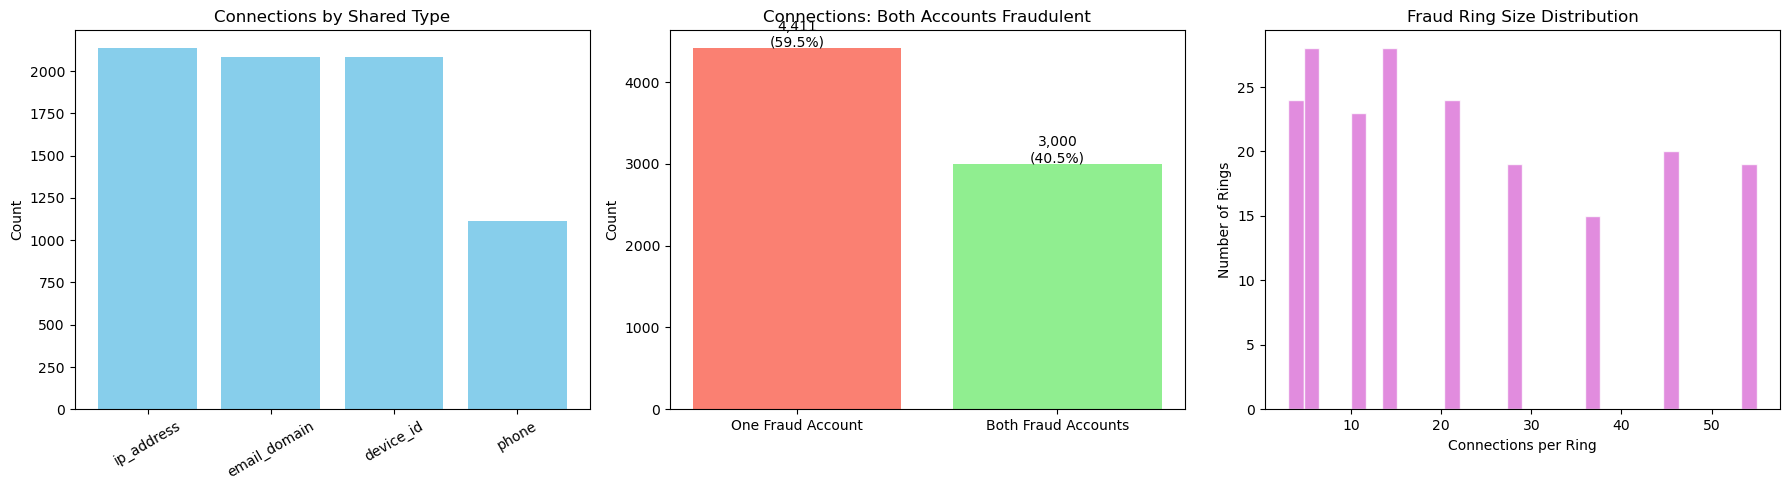

In [94]:
fig, axes = plt.subplots(1, 3, figsize = (18,5))

#Connection type breakdown
shared_type_counts = network_edges["shared_type"].value_counts()
axes[0].bar(shared_type_counts.index, shared_type_counts.values, color="skyblue")
axes[0].set_title("Connections by Shared Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

#Both-fraud flag
both_fraud_counts = network_edges["both_fraud"].value_counts()
axes[1].bar(["One Fraud Account", "Both Fraud Accounts"], both_fraud_counts.values, color=["salmon", "lightgreen"])
axes[1].set_title("Connections: Both Accounts Fraudulent")
axes[1].set_ylabel("Count")
for i, v in enumerate(both_fraud_counts.values):
    axes[1].text(i, v + 20, f"{v:,}\n({v/len(network_edges)*100:.1f}%)", ha="center")

#Ring size distribution
ring_sizes = network_edges.dropna(subset = ["ring_id"]).groupby("ring_id")["account_a"].count()
axes[2].hist(ring_sizes, bins = 30, color = "orchid", alpha = 0.8, edgecolor = "white")
axes[2].set_title("Fraud Ring Size Distribution")
axes[2].set_ylabel("Number of Rings")
axes[2].set_xlabel("Connections per Ring")

plt.tight_layout()

print(f"Total edges: {len(network_edges):,}")
print(f"Edges where both accounts are fraudulent: {network_edges['both_fraud'].sum():,}")
print(f"Edges in identified rings: {network_edges['ring_id'].notna().sum():,}")
print(f"Unique rings: {network_edges['ring_id'].nunique(dropna=True):,}")